In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv('UK Gender Pay Gap Data - 2024 to 2025.csv')
df.head()

,EmployerName,EmployerId,Address,PostCode,CompanyNumber,SicCodes,DiffMeanHourlyPercent,DiffMedianHourlyPercent,DiffMeanBonusPercent,DiffMedianBonusPercent,...,FemaleUpperMiddleQuartile,MaleTopQuartile,FemaleTopQuartile,CompanyLinkToGPGInfo,ResponsiblePerson,EmployerSize,CurrentName,SubmittedAfterTheDeadline,DueDate,DateSubmitted
0,'PRIFYSGOL ABERYSTWYTH' AND 'ABERYSTWYTH UNIVE...,19070,"Aberystwyth University, Penglais, Ceredigion, ...",SY23 3FL,RC000641,NaN,9.17,2.90,7.50,0.00,...,60.33,53.62,46.38,https://www.aber.ac.uk/en/equality/equality-re...,Dylan Jones (dej20@aber.ac.uk),1000 to 4999,'PRIFYSGOL ABERYSTWYTH' AND 'ABERYSTWYTH UNIVE...,False,2025/04/05 00:00:00,2025/03/28 09:02:53
1,"""RED BAND"" CHEMICAL COMPANY, LIMITED",16879,"19 Smith's Place, Leith Walk, Edinburgh, EH6 8NU",EH6 8NU,SC016876,47730,8.75,-4.96,20.83,36.88,...,89.50,26.10,73.90,NaN,Osmond Ramsay (Managing Director),250 to 499,"""RED BAND"" CHEMICAL COMPANY, LIMITED",True,2025/04/05 00:00:00,2025/04/11 07:57:32
2,10 TRINITY SQUARE HOTEL LIMITED,19455,"5 Market Yard Mews, 194-204 Bermondsey Street,...",SE1 3TQ,08064685,82990,-2.20,8.40,-93.90,0.00,...,34.00,63.00,37.00,https://www.fourseasons.com/towerbridge/,Linda Stigter (Director of People and Culture),250 to 499,10 TRINITY SQUARE HOTEL LIMITED,False,2025/04/05 00:00:00,2025/01/21 14:19:52
3,10442565 LTD,19491,"Compass House 17-19 Empringham Street, Kingsto...",HU9 1RP,10442565,70229,11.00,3.60,26.10,4.90,...,33.20,60.00,40.00,NaN,David Maccormack (Director),1000 to 4999,10442565 LTD,False,2025/04/05 00:00:00,2025/04/03 12:14:38
4,1509 GROUP,15320,"Royal Grammar School, High Street, Guildford, ...",GU1 3BB,04104101,"85200,\n85310",20.12,17.48,NaN,NaN,...,52.94,73.53,26.47,http://www.rgsg.co.uk,Catherine Perceval (Bursar),250 to 499,1509 GROUP,False,2025/04/05 00:00:00,2025/03/28 11:23:54


In [2]:
# Check for nulls in the column DiffMeanHourlyPercent
df['DiffMeanHourlyPercent'].isnull().sum()

np.int64(0)

In [3]:
# Keep only the first SIC code
df['SicCodes'] = df['SicCodes'].astype(str).str.split(',|\n').str[0]
df['SicCodes'] = df['SicCodes'].replace ('nan', pd.NA)

In [4]:
# Check nulls in column SicCodes
df['SicCodes'].isnull().sum()

np.int64(908)

In [5]:
# Remove rows where the SicCodes is missing
df_sic = df.dropna(subset=['SicCodes'])

In [6]:
from scipy import stats

# One-sample t-test against 0
t_stats, p_value = stats.ttest_1samp(df['DiffMeanHourlyPercent'], 0)

print(f"T-statistic: {t_stats:.3f}")
print(f"P-value: {p_value:.5f}")


T-statistic: 87.229
P-value: 0.00000


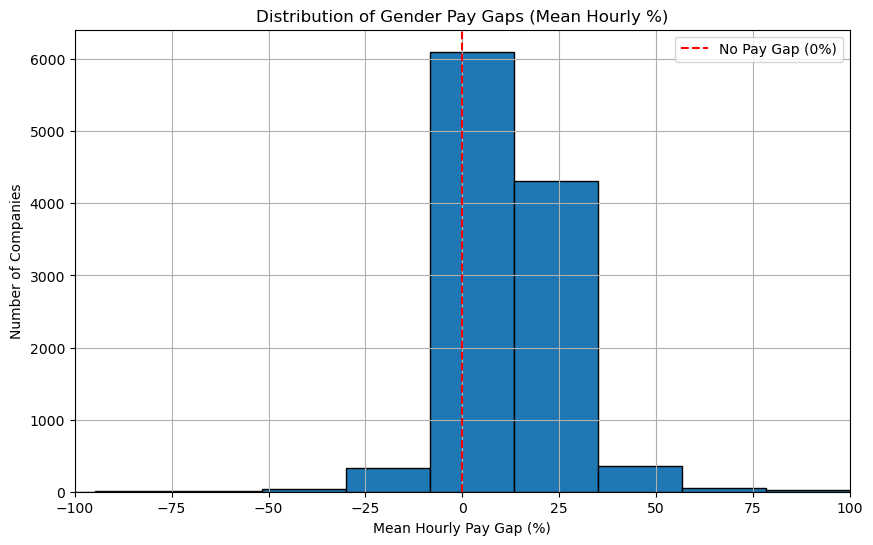

In [7]:
# Histogram distribution of gender pay gap
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['DiffMeanHourlyPercent'], bins=30, edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='No Pay Gap (0%)')
plt.title('Distribution of Gender Pay Gaps (Mean Hourly %)')
plt.xlabel('Mean Hourly Pay Gap (%)')
plt.ylabel('Number of Companies')
plt.xlim(-100, 100) # Focus on relistic range
plt.legend()
plt.grid(True)
plt.show()

In [8]:
# Statistical summaries
df['DiffMeanHourlyPercent'].describe()

count    11226.000000
mean        12.000692
std         14.576652
min       -549.700000
25%          3.700000
50%         11.100000
75%         19.500000
max        100.000000
Name: DiffMeanHourlyPercent, dtype: float64

In [9]:
# Group by industry code and calculate average pay gap
industry_avg = df.groupby('SicCodes')['DiffMeanHourlyPercent'].mean().sort_values(ascending=False)
industry_top10 = industry_avg.head(10) # Show 10 industries with the largest gaps
industry_top10
                          

SicCodes
93120    58.082778
86230    40.917273
65202    35.200000
43991    34.545000
46431    34.300000
23510    33.900000
14142    33.800000
37000    33.553333
66120    33.071429
64991    30.700000
Name: DiffMeanHourlyPercent, dtype: float64

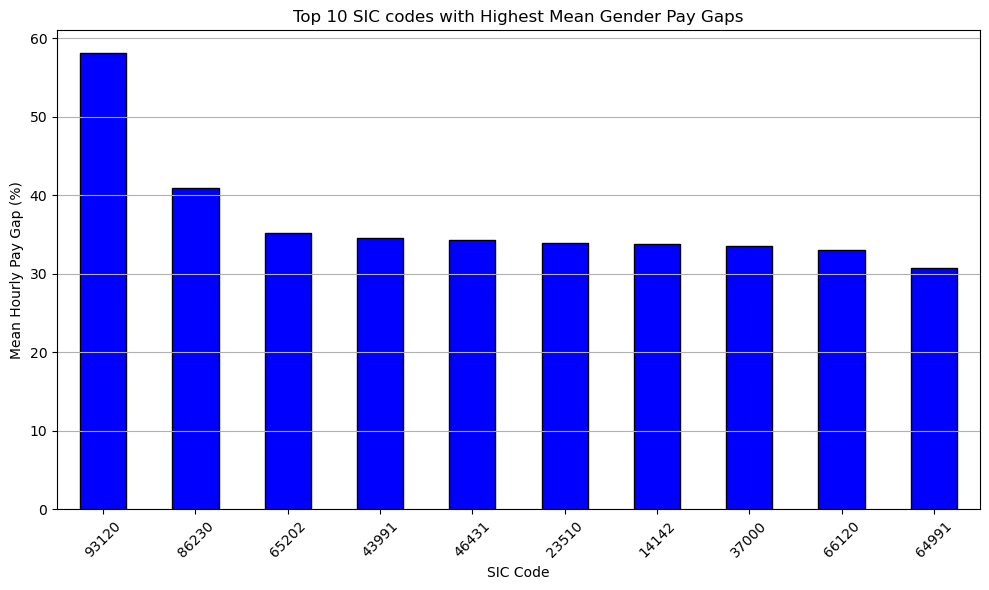

In [10]:
# Bar chart visualizes top 10 SIC codes with highest mean gender pay gaps
plt.figure(figsize=(10, 6))
industry_top10.plot(kind='bar', color='blue', edgecolor='black')
plt.title('Top 10 SIC codes with Highest Mean Gender Pay Gaps')
plt.xlabel('SIC Code')
plt.ylabel('Mean Hourly Pay Gap (%)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [11]:
# Correlation between DiffMeanHourlyPercent and FemaleUpperMiddleQuartile
df[['DiffMeanHourlyPercent', 'FemaleUpperMiddleQuartile']].corr()

,DiffMeanHourlyPercent,FemaleUpperMiddleQuartile
DiffMeanHourlyPercent,1.000000,0.044227
FemaleUpperMiddleQuartile,0.044227,1.000000
